In [5]:
from transformers import AutoTokenizer

# 你可以换成 "mistralai/Mistral-7B-v0.1" 或其他你本地有的模型
model_name = "camemBERT-base"  # 例如 camemBERT-base 或其他适合处理法语的模型
tokenizer = AutoTokenizer.from_pretrained(model_name)

text_std = "Les femmes sont très joyeuses."
text_inc = "Les meufs sont très joyeuses."

# 1. 对比切分结果
tokens_std = tokenizer.tokenize(text_std)
tokens_inc = tokenizer.tokenize(text_inc)

print(f"=== 分词对比 ===")
print(f"标准版 ({len(tokens_std)} tokens): {tokens_std}")
print(f"包容版 ({len(tokens_inc)} tokens): {tokens_inc}")

# 2. 计算 Fertility (繁殖率)
# Fertility = 变体 Token 数量 / 标准 Token 数量
fertility = len(tokens_inc) / len(tokens_std)
print(f"Fertility 繁殖率: {fertility:.2f}")

=== 分词对比 ===
标准版 (7 tokens): ['▁Les', '▁femmes', '▁sont', '▁très', '▁joyeuse', 's', '.']
包容版 (9 tokens): ['▁Les', '▁me', 'uf', 's', '▁sont', '▁très', '▁joyeuse', 's', '.']
Fertility 繁殖率: 1.29


In [ ]:
import torch
from transformers import AutoModel, AutoTokenizer

# 假设你之前已经定义了 model_name 和文本
# model_name = "camembert-base" 
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# text_std = "Les directeurs sont très compétents."
# text_inc = "Les directeur·trice·s sont très compétent·e·s."
from transformers import AutoTokenizer


# 把 token 传给分词器
tokenizer = AutoTokenizer.from_pretrained(model_name, token=my_token)

# 后面的代码保持不变...
# 加载模型，并强制要求输出隐藏层和注意力矩阵
model = AutoModel.from_pretrained(model_name, output_hidden_states=True, output_attentions=True)

# 将文本转为模型可读的张量 (Tensors)
inputs_std = tokenizer(text_std, return_tensors="pt")
inputs_inc = tokenizer(text_inc, return_tensors="pt")

# 闭包计算，不需要更新梯度（节省内存和算力）
with torch.no_grad():
    outputs_std = model(**inputs_std)
    outputs_inc = model(**inputs_inc)

print("\n=== 模型内部特征提取（严格同类对比） ===")

# ==========================================
# 1. 隐藏层 (Hidden States) 对比
# outputs.hidden_states 包含所有层，我们取最后一层 [-1]
# 理论维度: [Batch_size, Sequence_length (词数), Hidden_size]
# ==========================================
last_hidden_state_std = outputs_std.hidden_states[-1] 
last_hidden_state_inc = outputs_inc.hidden_states[-1] 

print("\n--- 1. 隐藏层 (Hidden States) 维度对比 ---")
print(f"标准句: {last_hidden_state_std.shape}  -> 句子长度为 {last_hidden_state_std.shape[1]} 个Token") 
print(f"包容句: {last_hidden_state_inc.shape} -> 句子长度暴增为 {last_hidden_state_inc.shape[1]} 个Token！") 


# ==========================================
# 2. 注意力矩阵 (Attention Weights) 对比
# outputs.attentions 包含所有层，我们同样取最后一层 [-1]
# 理论维度: [Batch_size, Num_heads, Sequence_length (词数), Sequence_length (词数)]
# ==========================================
last_layer_attention_std = outputs_std.attentions[-1]
last_layer_attention_inc = outputs_inc.attentions[-1]

print("\n--- 2. 注意力矩阵 (Attention) 维度对比 ---")
print(f"标准句: {last_layer_attention_std.shape}   -> 注意力在一个 {last_layer_attention_std.shape[2]} x {last_layer_attention_std.shape[3]} 的小网格里计算")
print(f"包容句: {last_layer_attention_inc.shape} -> 注意力迷失在一个 {last_layer_attention_inc.shape[2]} x {last_layer_attention_inc.shape[3]} 的大网格里！")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2062.41it/s]
CamembertModel LOAD REPORT from: camemBERT-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== 模型内部特征提取（严格同类对比） ===

--- 1. 隐藏层 (Hidden States) 维度对比 ---
标准句: torch.Size([1, 9, 768])  -> 句子长度为 9 个Token
包容句: torch.Size([1, 11, 768]) -> 句子长度暴增为 11 个Token！

--- 2. 注意力矩阵 (Attention) 维度对比 ---
标准句: torch.Size([1, 12, 9, 9])   -> 注意力在一个 9 x 9 的小网格里计算
包容句: torch.Size([1, 12, 11, 11]) -> 注意力迷失在一个 11 x 11 的大网格里！


In [7]:
print("标准句切分:", tokenizer.convert_ids_to_tokens(inputs_std["input_ids"][0]))
print("包容句切分:", tokenizer.convert_ids_to_tokens(inputs_inc["input_ids"][0]))

标准句切分: ['<s>', '▁Les', '▁femmes', '▁sont', '▁très', '▁joyeuse', 's', '.', '</s>']
包容句切分: ['<s>', '▁Les', '▁me', 'uf', 's', '▁sont', '▁très', '▁joyeuse', 's', '.', '</s>']


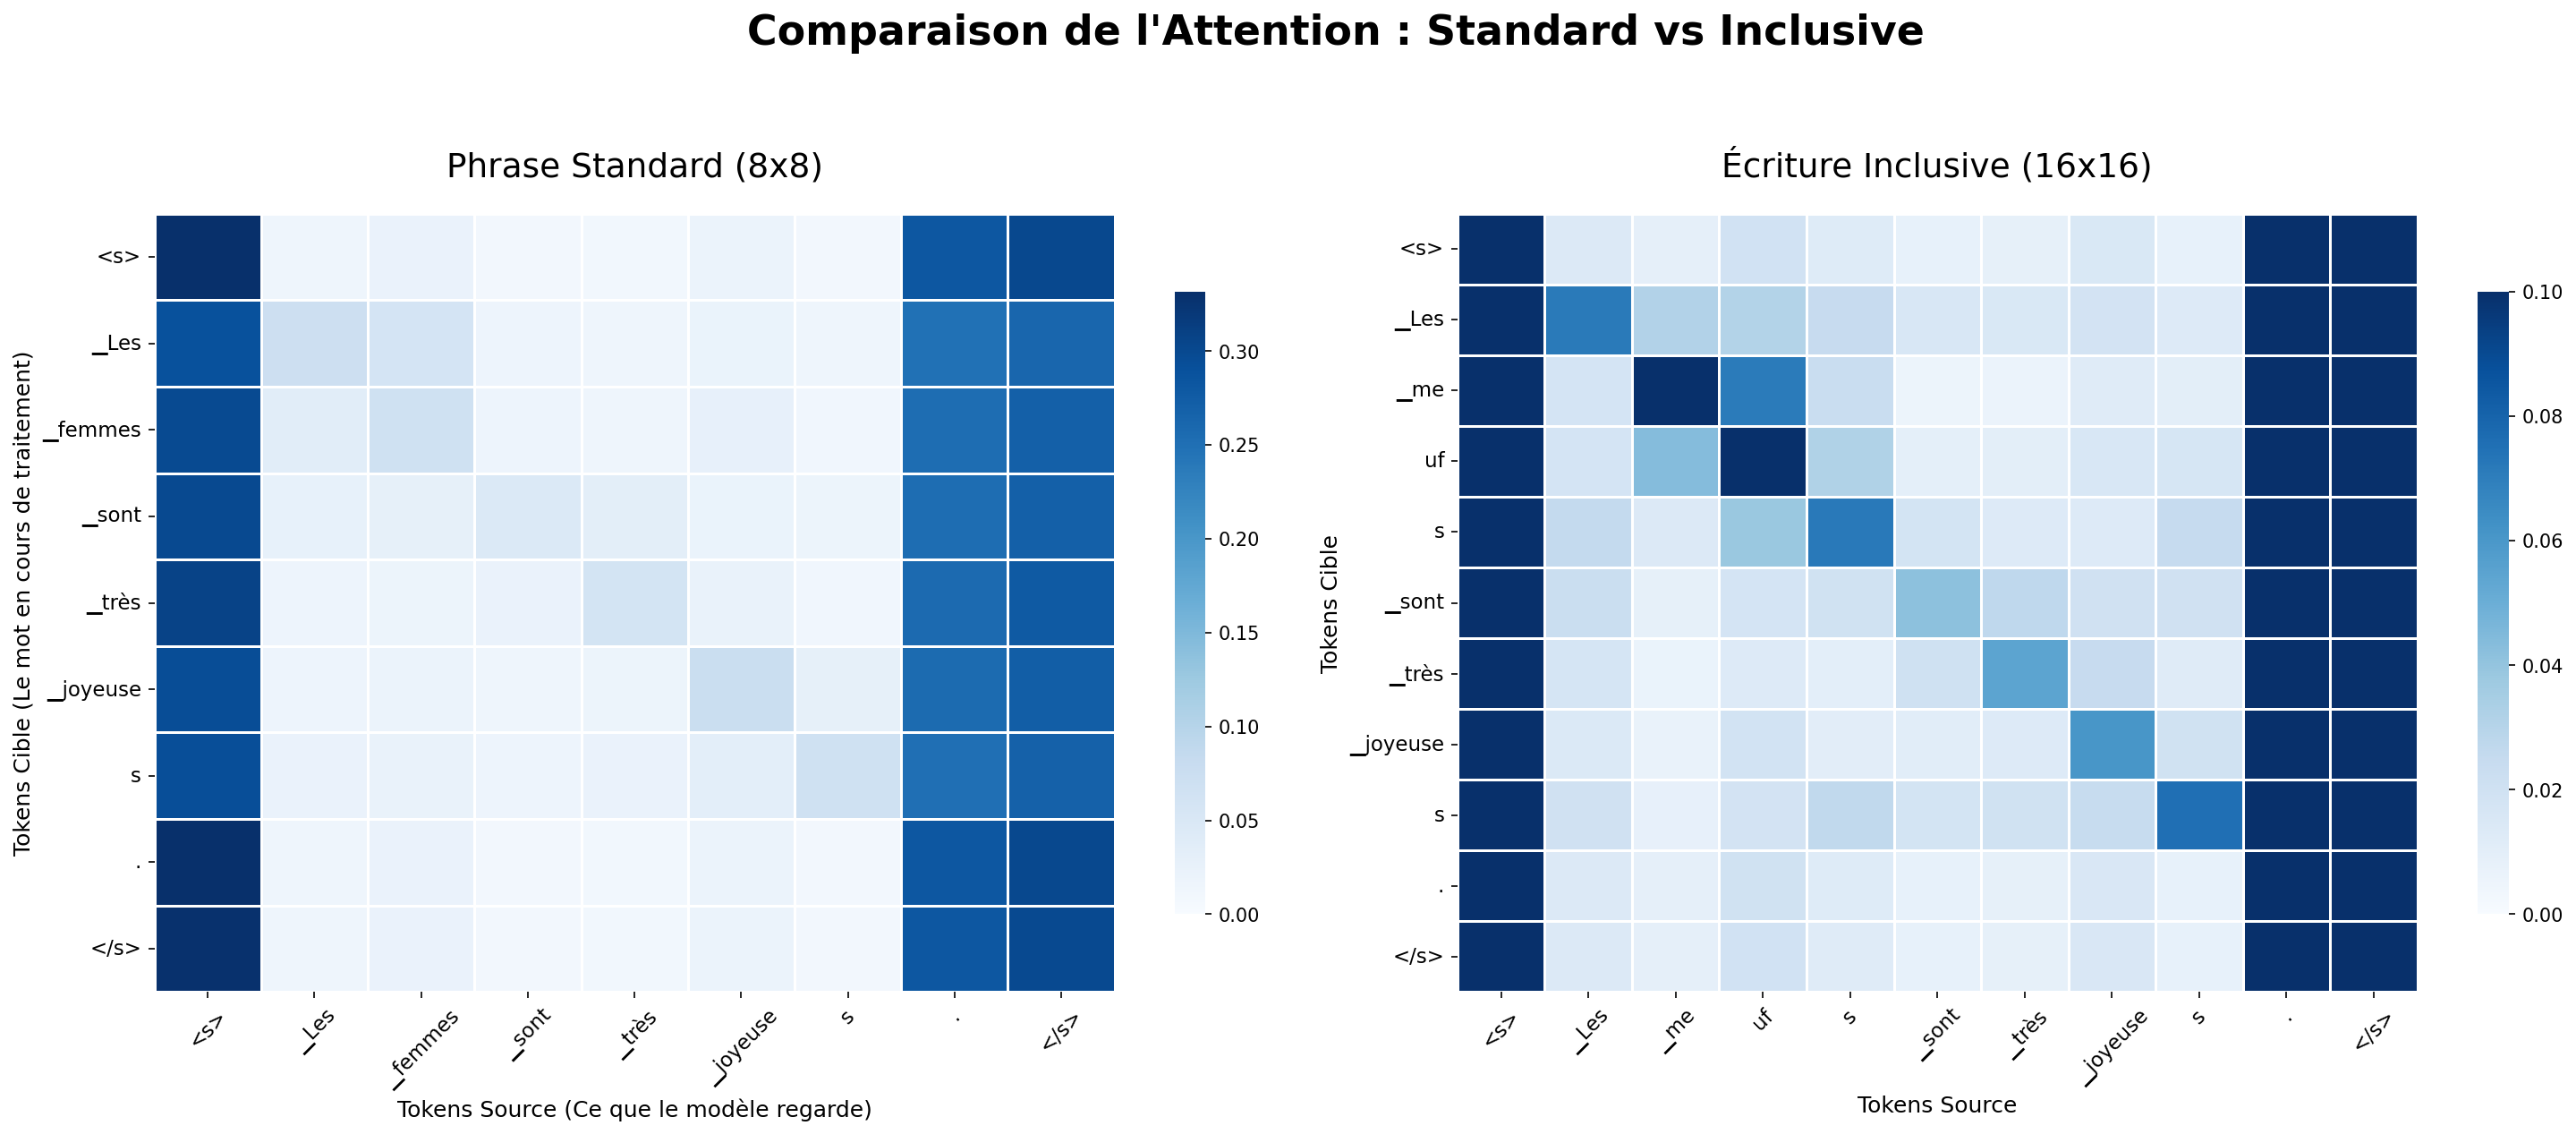

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ==========================================
# 第一步：准备 X轴和 Y轴的 Token 标签
# ==========================================
# 把 input_ids 转换回人类可读的词汇碎片
tokens_std = tokenizer.convert_ids_to_tokens(inputs_std["input_ids"][0])
tokens_inc = tokenizer.convert_ids_to_tokens(inputs_inc["input_ids"][0])

# ==========================================
# 第二步：提取并处理两个句子的注意力矩阵
# ==========================================
# 提取最后一层，去掉 Batch 维度，并在 12 个注意力头上求平均，最后转为 numpy 数组
attention_matrix_std = outputs_std.attentions[-1].squeeze(0).mean(dim=0).detach().numpy()
attention_matrix_inc = outputs_inc.attentions[-1].squeeze(0).mean(dim=0).detach().numpy()

# 为了让两张图的颜色深浅具有绝对的可比性，我们找出两张图里的全局最大值
# 这样左图和右图的“深蓝色”代表的是同一个级别的注意力强度
global_max = max(attention_matrix_std.max(), attention_matrix_inc.max())

# ==========================================
# 第三步：绘制双图并排对比热力图 (Side-by-Side Heatmaps)
# ==========================================
# 创建一个宽 20，高 8 的大画布，包含 1 行 2 列两个子图 (ax1 和 ax2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

# --- 绘制左图：标准句 (8x8) ---
sns.heatmap(attention_matrix_std, 
            ax=ax1, # 指定画在左边的子图
            xticklabels=tokens_std, 
            yticklabels=tokens_std, 
            cmap="Blues", 
            linewidths=0.5, 
            vmin=0, vmax=global_max, # 统一颜色刻度
            cbar_kws={"shrink": 0.8}) # 稍微缩小一点颜色条

ax1.set_title("Phrase Standard (8x8)", fontsize=18, pad=20)
ax1.set_xlabel("Tokens Source (Ce que le modèle regarde)", fontsize=12)
ax1.set_ylabel("Tokens Cible (Le mot en cours de traitement)", fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=11)
ax1.tick_params(axis='y', rotation=0, labelsize=11)

# --- 绘制右图：包容性书写 (16x16) ---
sns.heatmap(attention_matrix_inc, 
            ax=ax2, # 指定画在右边的子图
            xticklabels=tokens_inc, 
            yticklabels=tokens_inc, 
            cmap="Blues", 
            linewidths=0.5, 
            vmin=0, vmax=0.1, # 统一颜色刻度
            cbar_kws={"shrink": 0.8})

ax2.set_title("Écriture Inclusive (16x16)", fontsize=18, pad=20)
ax2.set_xlabel("Tokens Source", fontsize=12)
ax2.set_ylabel("Tokens Cible", fontsize=12)
ax2.tick_params(axis='x', rotation=45, labelsize=11)
ax2.tick_params(axis='y', rotation=0, labelsize=11)

# ==========================================
# 第四步：微调排版并显示
# ==========================================
# 添加一个总标题
plt.suptitle("Comparaison de l'Attention : Standard vs Inclusive", fontsize=22, fontweight='bold', y=1.05)

# 自动调整子图之间的间距，防止文字重叠
plt.tight_layout()

# 展示高清大图
plt.show()

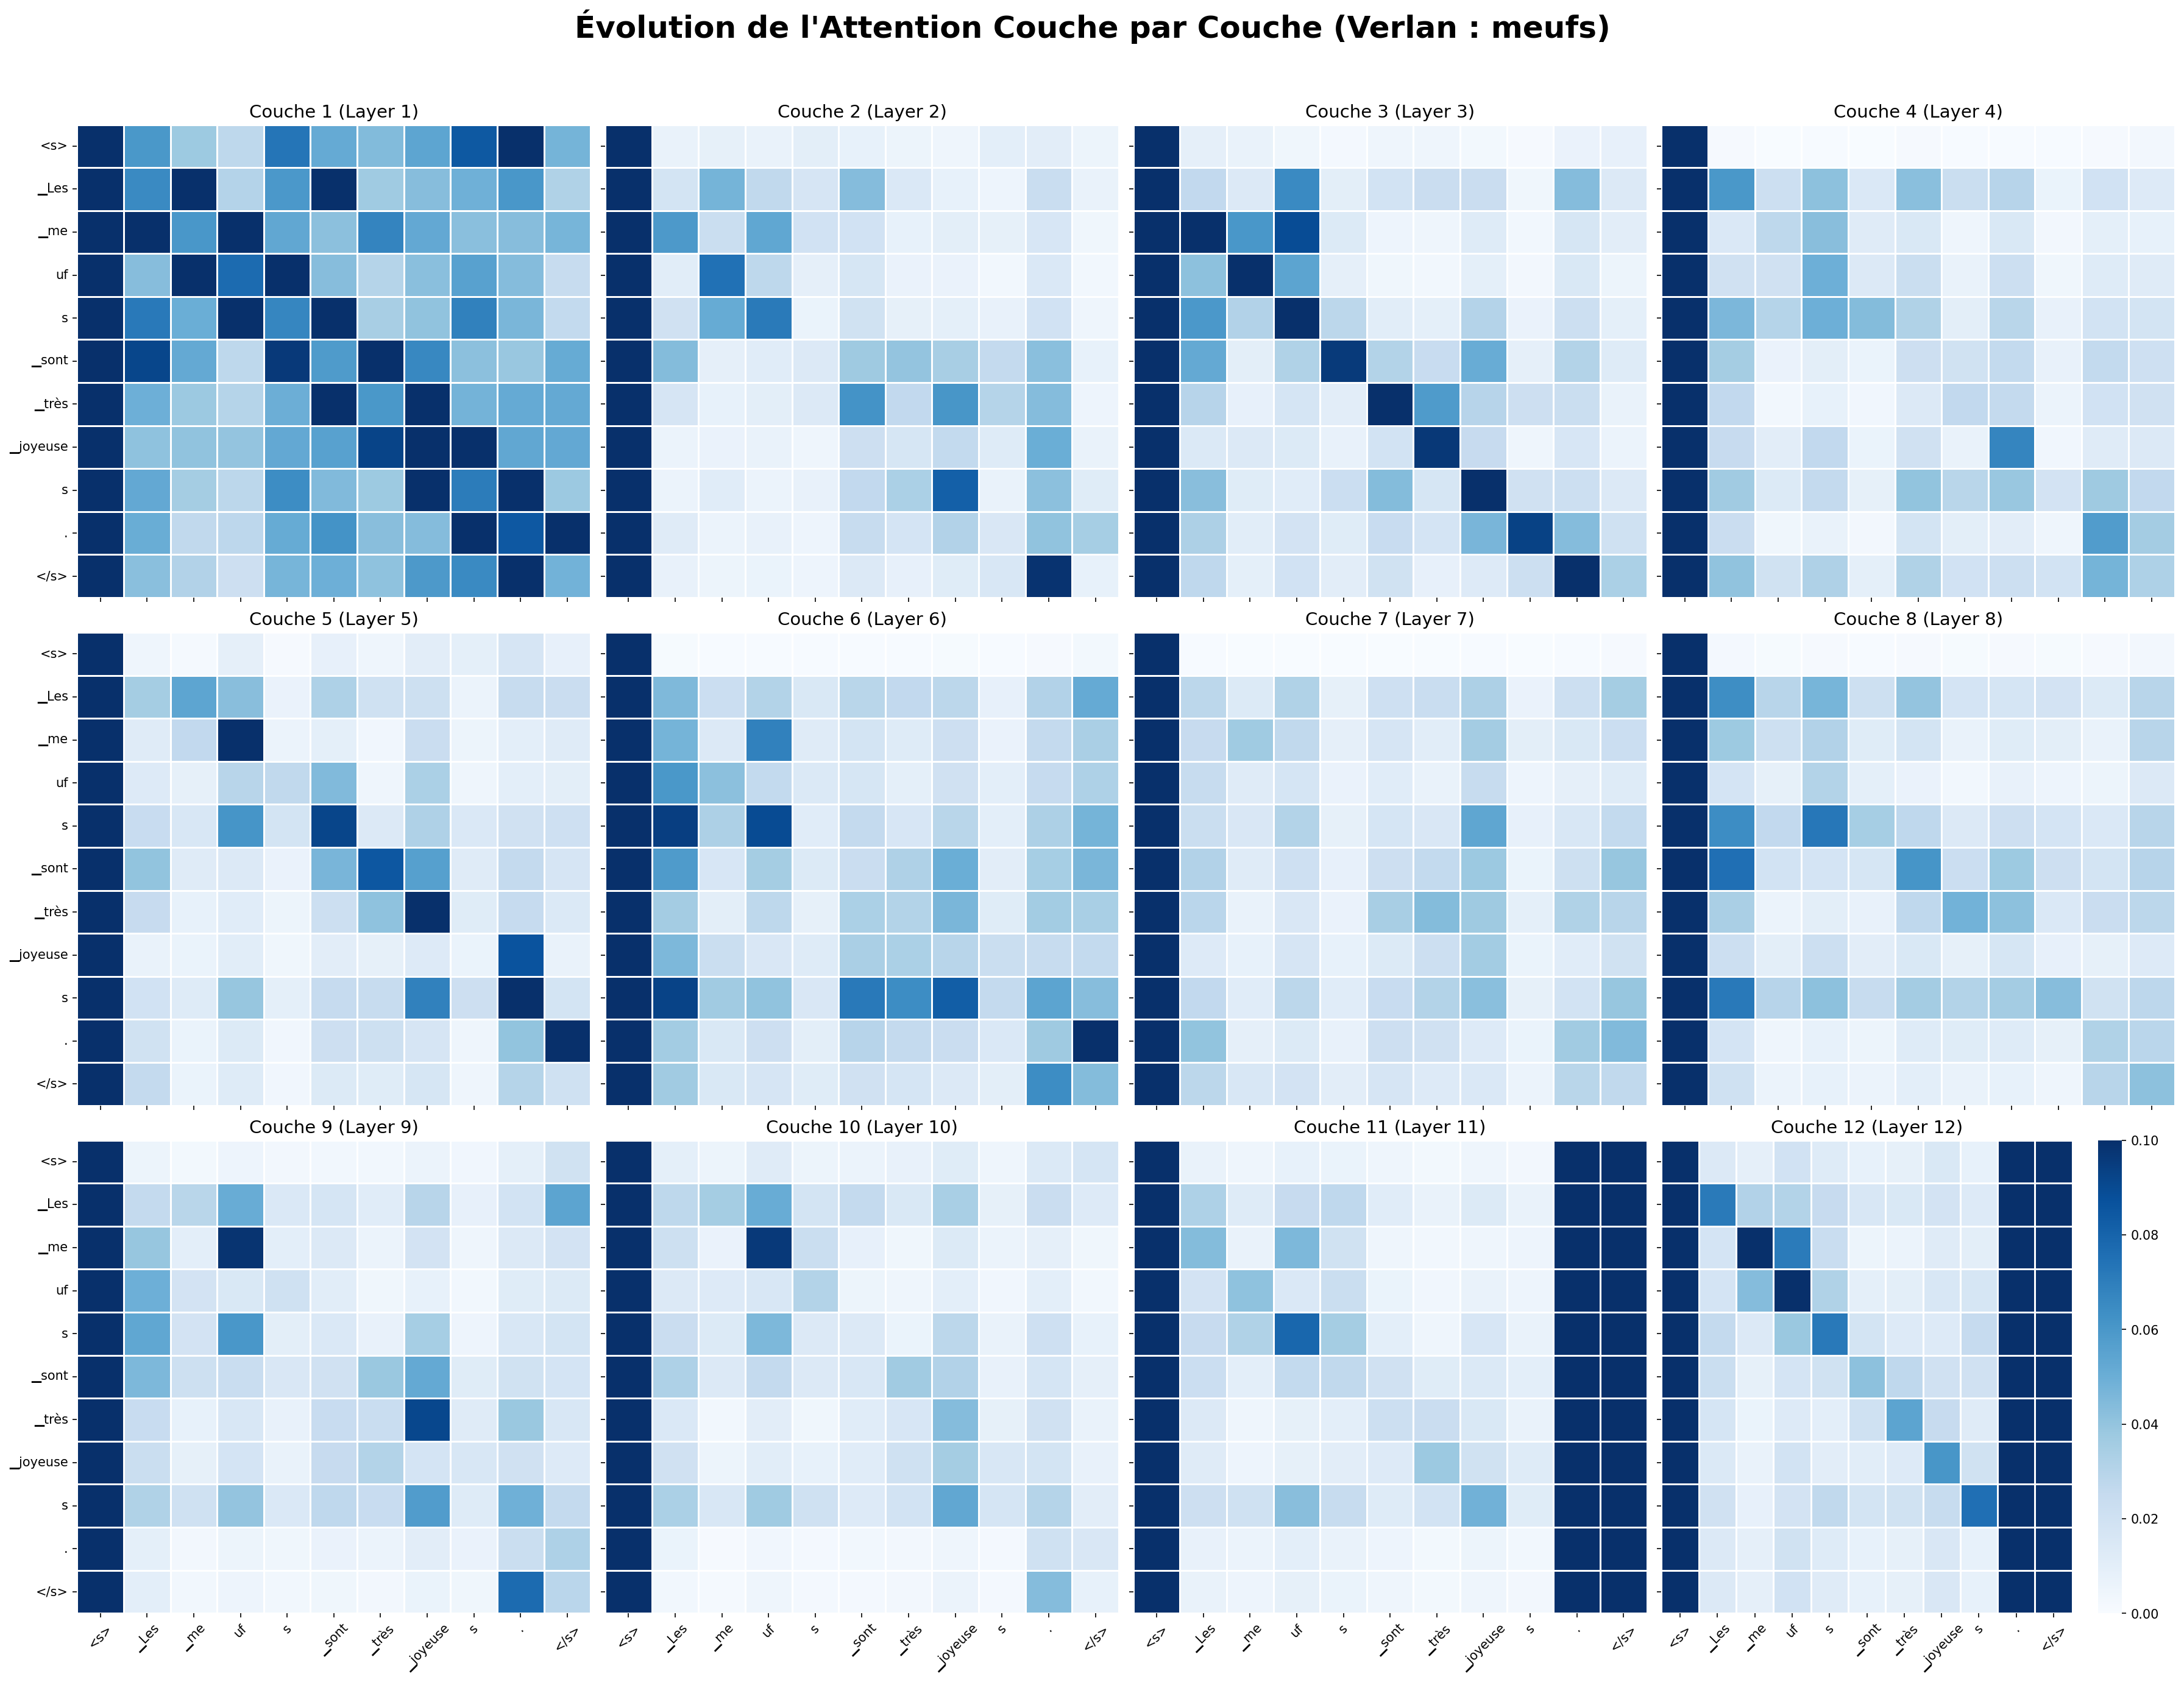

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import math

# 提取 Verlan 句子的 Token 标签
tokens_inc = tokenizer.convert_ids_to_tokens(inputs_inc["input_ids"][0])

# 获取模型的总层数 (通常 base 模型是 12 层)
num_layers = len(outputs_inc.attentions)

# 创建一个 3行 4列 的大画布 (适合 12 层的模型)
fig, axes = plt.subplots(3, 4, figsize=(24, 18), dpi=150)
axes = axes.flatten() # 把 2D 坐标轴数组拉平，方便循环

# 为了让颜色对比有意义，我们算一下所有层里的最大注意力值
global_max = 0
for i in range(num_layers):
    layer_attn = outputs_inc.attentions[i].squeeze(0).mean(dim=0).detach().numpy()
    global_max = max(global_max, layer_attn.max())

# 循环遍历每一层并画图
for i in range(num_layers):
    # 提取第 i 层的注意力矩阵 (并在 12 个头上求平均)
    layer_attn = outputs_inc.attentions[i].squeeze(0).mean(dim=0).detach().numpy()
    
    # 在对应的子图上画热力图
    sns.heatmap(layer_attn, 
                ax=axes[i], 
                xticklabels=tokens_inc,
                yticklabels=tokens_inc, 
                cmap="Blues", 
                linewidths=0.5,
                vmin=0, vmax=0.1, # 统一颜色标尺
                cbar=(i == 11)) # 只在最后一张图画颜色条，保持画面干净
    
    # 设置子图标题
    axes[i].set_title(f"Couche {i+1} (Layer {i+1})", fontsize=14)
    
    # 调整坐标轴字体，隐藏内部坐标轴标签以防拥挤
    if i >= 8: # 只在最下面一行显示 X 轴标签
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)
    else:
        axes[i].set_xticklabels([])
        
    if i % 4 == 0: # 只在最左边一列显示 Y 轴标签
        axes[i].tick_params(axis='y', rotation=0, labelsize=10)
    else:
        axes[i].set_yticklabels([])

# 添加总标题
plt.suptitle("Évolution de l'Attention Couche par Couche (Verlan : meufs)", fontsize=24, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

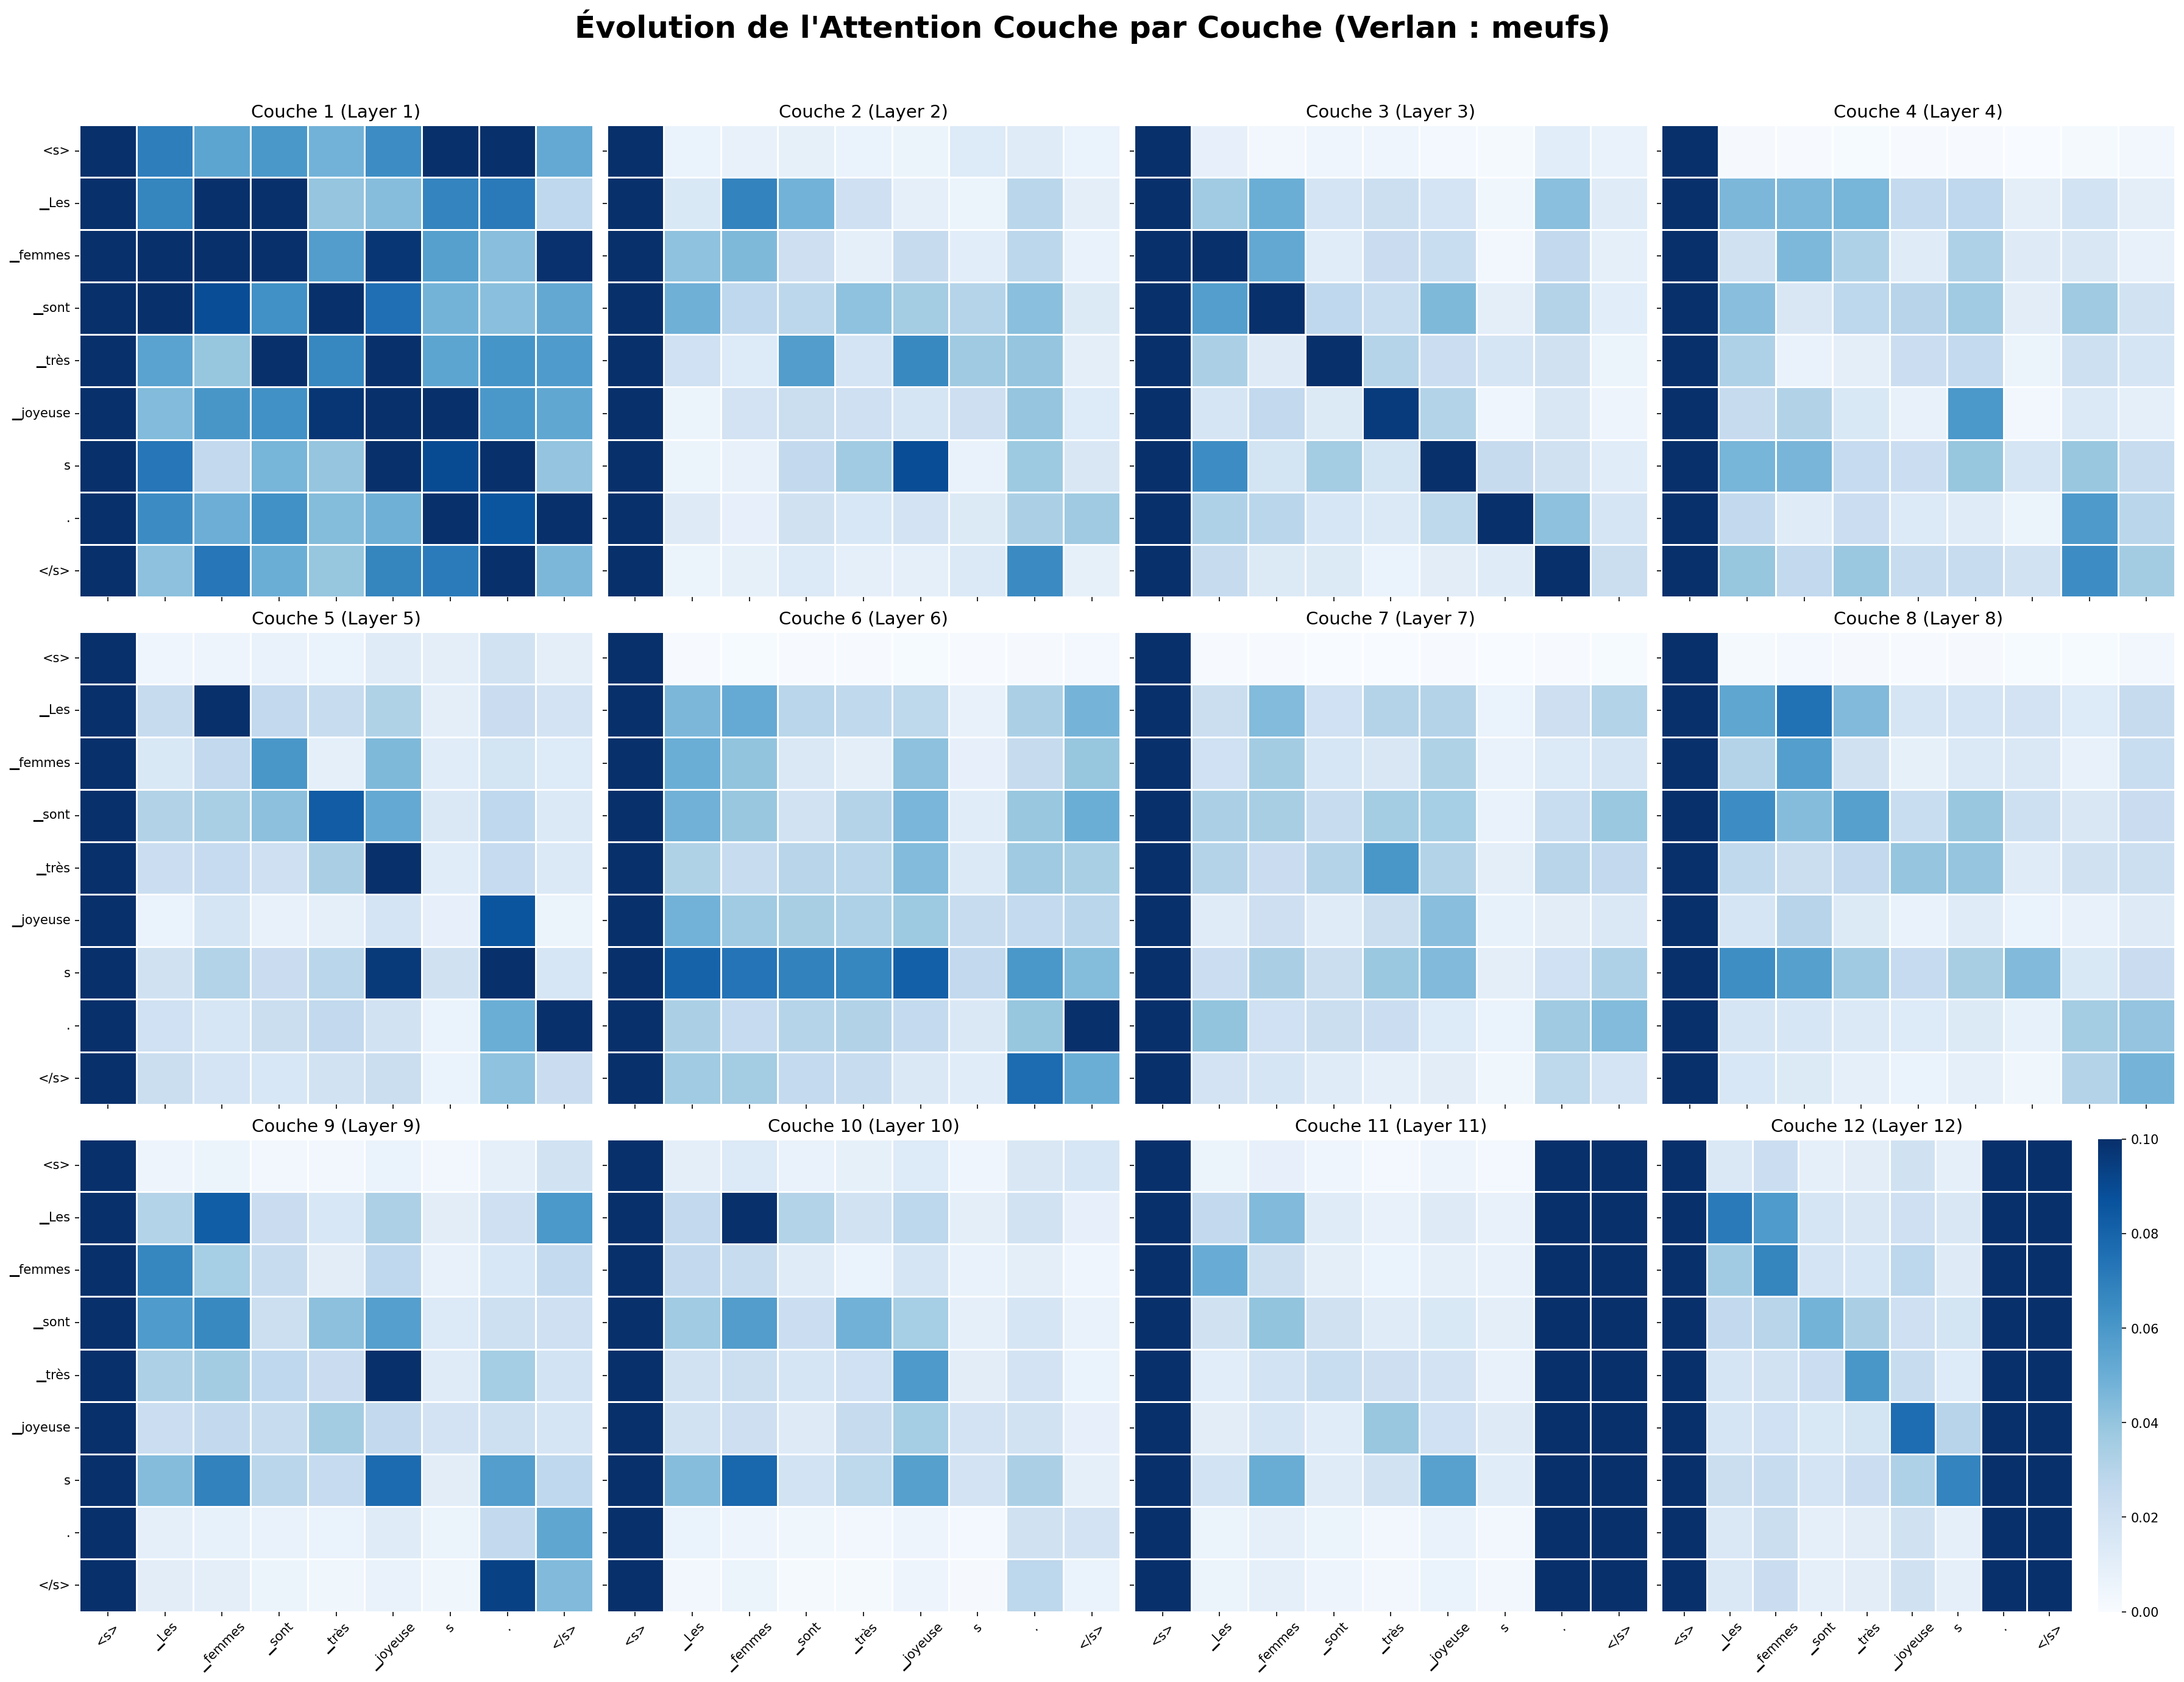

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import math

# 提取 Verlan 句子的 Token 标签
tokens_inc = tokenizer.convert_ids_to_tokens(inputs_std["input_ids"][0])

# 获取模型的总层数 (通常 base 模型是 12 层)
num_layers = len(outputs_std.attentions)

# 创建一个 3行 4列 的大画布 (适合 12 层的模型)
fig, axes = plt.subplots(3, 4, figsize=(24, 18), dpi=150)
axes = axes.flatten() # 把 2D 坐标轴数组拉平，方便循环

# 为了让颜色对比有意义，我们算一下所有层里的最大注意力值
global_max = 0
for i in range(num_layers):
    layer_attn = outputs_std.attentions[i].squeeze(0).mean(dim=0).detach().numpy()
    global_max = max(global_max, layer_attn.max())

# 循环遍历每一层并画图
for i in range(num_layers):
    # 提取第 i 层的注意力矩阵 (并在 12 个头上求平均)
    layer_attn = outputs_std.attentions[i].squeeze(0).mean(dim=0).detach().numpy()
    
    # 在对应的子图上画热力图
    sns.heatmap(layer_attn, 
                ax=axes[i], 
                xticklabels=tokens_inc,
                yticklabels=tokens_inc, 
                cmap="Blues", 
                linewidths=0.5,
                vmin=0, vmax=0.1, # 统一颜色标尺
                cbar=(i == 11)) # 只在最后一张图画颜色条，保持画面干净
    
    # 设置子图标题
    axes[i].set_title(f"Couche {i+1} (Layer {i+1})", fontsize=14)
    
    # 调整坐标轴字体，隐藏内部坐标轴标签以防拥挤
    if i >= 8: # 只在最下面一行显示 X 轴标签
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)
    else:
        axes[i].set_xticklabels([])
        
    if i % 4 == 0: # 只在最左边一列显示 Y 轴标签
        axes[i].tick_params(axis='y', rotation=0, labelsize=10)
    else:
        axes[i].set_yticklabels([])

# 添加总标题
plt.suptitle("Évolution de l'Attention Couche par Couche (Verlan : meufs)", fontsize=24, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()